In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("climate_trend_dataset_up.csv")

In [3]:
df . head ()

,date,region,avg_temperature_c,precipitation_mm,co2_ppm,temperature_anomaly_c,humidity_percent
0,01-01-2010,West,3.37,47.39,388.64,-0.24,53.69
1,02-01-2010,Central,13.50,22.00,391.97,0.05,81.52
2,03-01-2010,East,10.85,83.16,387.47,-0.33,59.11
3,04-01-2010,Central,8.48,50.35,391.20,-0.53,51.05
4,05-01-2010,Central,10.05,64.55,388.14,0.02,70.34


In [5]:
df.tail()

,date,region,avg_temperature_c,precipitation_mm,co2_ppm,temperature_anomaly_c,humidity_percent
4995,05-09-2023,West,24.16,82.52,437.06,2.81,70.32
4996,06-09-2023,West,18.55,45.52,436.89,2.13,46.14
4997,07-09-2023,Central,15.26,48.55,435.75,2.91,63.42
4998,08-09-2023,West,19.37,79.80,434.78,2.05,46.93
4999,09-09-2023,Central,15.32,66.31,435.77,2.26,72.63


In [6]:
df.sample(5)


,date,region,avg_temperature_c,precipitation_mm,co2_ppm,temperature_anomaly_c,humidity_percent
3437,31-05-2019,West,17.80,35.81,423.66,1.35,67.72
4237,08-08-2021,North,20.45,57.56,430.27,1.94,54.94
1876,20-02-2015,North,21.09,17.38,406.57,0.91,64.48
2334,23-05-2016,North,16.70,53.94,408.69,1.09,59.23
2265,15-03-2016,South,8.23,65.44,409.90,1.31,64.15


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   5000 non-null   str    
 1   region                 5000 non-null   str    
 2   avg_temperature_c      5000 non-null   float64
 3   precipitation_mm       5000 non-null   float64
 4   co2_ppm                5000 non-null   float64
 5   temperature_anomaly_c  5000 non-null   float64
 6   humidity_percent       5000 non-null   float64
dtypes: float64(5), str(2)
memory usage: 273.6 KB


In [8]:
df.describe()

,avg_temperature_c,precipitation_mm,co2_ppm,temperature_anomaly_c,humidity_percent
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,16.149176,60.17607,412.541154,1.246596,65.035242
std,4.147459,24.25512,13.081580,0.777739,11.741166
min,2.480000,0.22000,387.470000,-0.970000,23.060000
25%,13.387500,43.66750,401.270000,0.620000,56.827500
50%,16.140000,59.98500,412.500000,1.250000,65.120000
75%,18.910000,76.34250,423.852500,1.870000,72.920000
max,30.990000,144.44000,439.060000,3.150000,100.000000


In [9]:
df.shape

(5000, 7)

In [10]:
df.columns

Index(['date', 'region', 'avg_temperature_c', 'precipitation_mm', 'co2_ppm',
       'temperature_anomaly_c', 'humidity_percent'],
      dtype='str')

In [11]:
df.isnull().sum()

date                     0
region                   0
avg_temperature_c        0
precipitation_mm         0
co2_ppm                  0
temperature_anomaly_c    0
humidity_percent         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [15]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month_name()

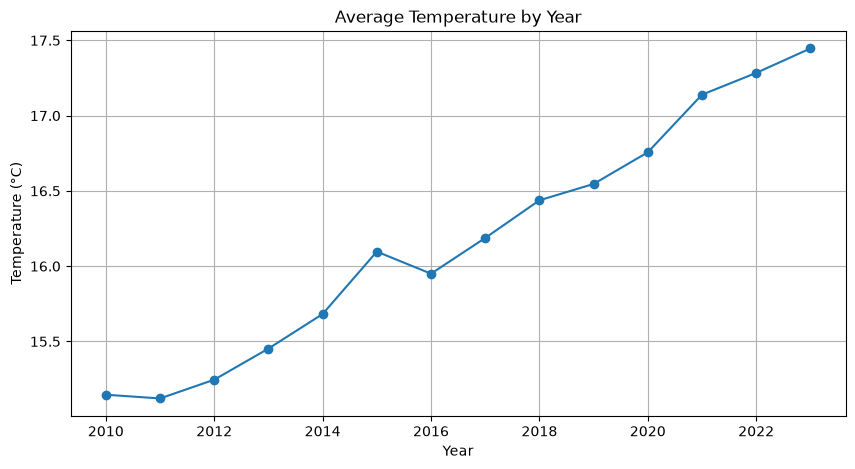

In [16]:
temp = df.groupby("Year")["avg_temperature_c"].mean()

plt.figure(figsize=(10,5))
plt.plot(temp.index, temp.values, marker="o")
plt.title("Average Temperature by Year")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

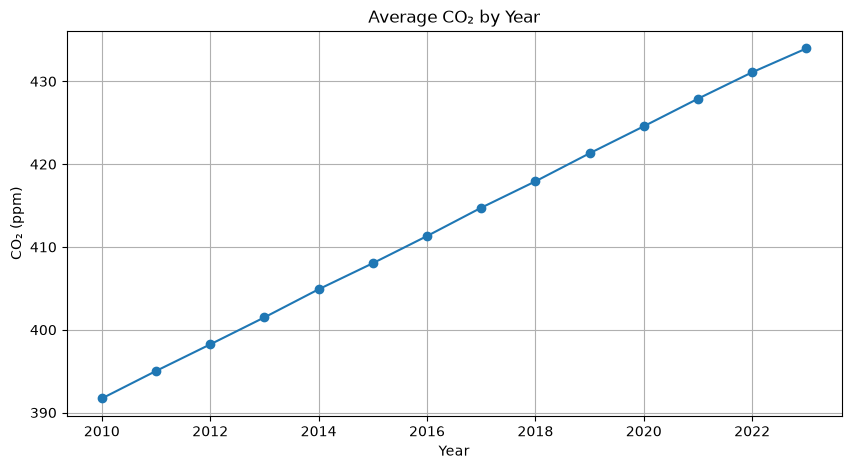

In [17]:
co2 = df.groupby("Year")["co2_ppm"].mean()

plt.figure(figsize=(10,5))
plt.plot(co2.index, co2.values, marker="o")
plt.title("Average CO₂ by Year")
plt.xlabel("Year")
plt.ylabel("CO₂ (ppm)")
plt.grid(True)
plt.show()

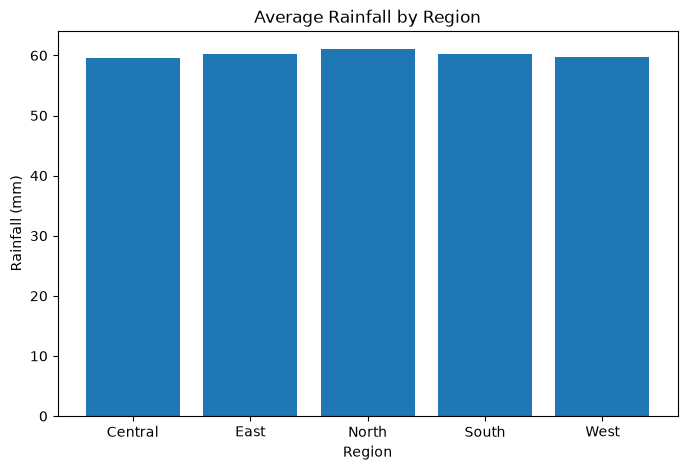

In [18]:
rain = df.groupby("region")["precipitation_mm"].mean()

plt.figure(figsize=(8,5))
plt.bar(rain.index, rain.values)
plt.title("Average Rainfall by Region")
plt.xlabel("Region")
plt.ylabel("Rainfall (mm)")
plt.show()

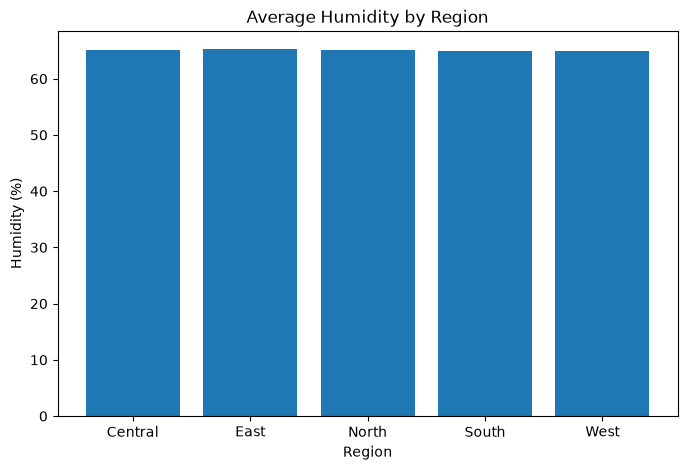

In [19]:
humidity = df.groupby("region")["humidity_percent"].mean()

plt.figure(figsize=(8,5))
plt.bar(humidity.index, humidity.values)
plt.title("Average Humidity by Region")
plt.xlabel("Region")
plt.ylabel("Humidity (%)")
plt.show()

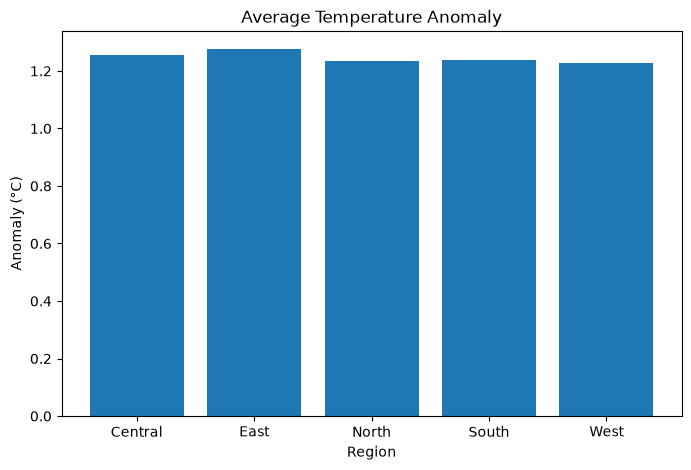

In [20]:
anomaly = df.groupby("region")["temperature_anomaly_c"].mean()

plt.figure(figsize=(8,5))
plt.bar(anomaly.index, anomaly.values)
plt.title("Average Temperature Anomaly")
plt.xlabel("Region")
plt.ylabel("Anomaly (°C)")
plt.show()

In [21]:
top10 = df.nlargest(10, "avg_temperature_c")
top10

,date,region,avg_temperature_c,precipitation_mm,co2_ppm,temperature_anomaly_c,humidity_percent,Year,Month
3739,2020-03-28,North,30.99,110.78,424.54,1.79,80.19,2020,March
4071,2021-02-23,Central,29.51,71.15,427.06,2.42,53.47,2021,February
4178,2021-06-10,South,28.86,37.90,427.80,1.83,76.25,2021,June
4720,2022-12-04,South,28.82,65.79,434.11,2.51,66.13,2022,December
2644,2017-03-29,West,28.72,12.41,413.33,0.73,78.90,2017,March
4722,2022-12-06,South,28.66,28.17,428.71,2.67,44.13,2022,December
3586,2019-10-27,Central,28.53,29.36,424.65,1.95,78.68,2019,October
1845,2015-01-20,Central,28.37,42.37,408.58,1.04,76.61,2015,January
4289,2021-09-29,North,28.31,43.83,426.80,2.38,73.05,2021,September
564,2011-07-19,West,28.25,76.11,396.50,0.21,79.11,2011,July


In [22]:
df.corr(numeric_only=True)

,avg_temperature_c,precipitation_mm,co2_ppm,temperature_anomaly_c,humidity_percent,Year
avg_temperature_c,1.000000,-0.016602,0.177576,0.167876,0.028810,0.178616
precipitation_mm,-0.016602,1.000000,-0.001758,0.003058,-0.016674,-0.004312
co2_ppm,0.177576,-0.001758,1.000000,0.914999,0.002667,0.990849
temperature_anomaly_c,0.167876,0.003058,0.914999,1.000000,-0.005029,0.919404
humidity_percent,0.028810,-0.016674,0.002667,-0.005029,1.000000,-0.003620
Year,0.178616,-0.004312,0.990849,0.919404,-0.003620,1.000000


In [23]:
df.groupby("region").agg({
    "avg_temperature_c":"mean",
    "co2_ppm":"mean",
    "precipitation_mm":"mean",
    "humidity_percent":"mean",
    "temperature_anomaly_c":"mean"
})

,avg_temperature_c,co2_ppm,precipitation_mm,humidity_percent,temperature_anomaly_c
region,,,,,
Central,16.128096,412.617832,59.636943,65.027529,1.254482
East,16.121913,413.028423,60.254832,65.217457,1.274985
North,16.199264,412.245309,61.000540,65.050255,1.235309
South,16.214073,412.461430,60.236176,65.018083,1.239295
West,16.084480,412.363647,59.756353,64.866799,1.229316


In [24]:
df.to_csv("Climate_Final.csv", index=False)